# Why the field, not the profile: reading $f_b$ off a realistic stacked observation

**The question, stated simply.** We want the baryon fraction $f_b$ of a cluster
population from what a survey actually measures: a *stacked* gas observable (tSZ
$Y(r)$, X-ray $S_X(r)$) around a mass-selected sample. Two emulators could supply
the training link observable $\to f_b$:

* a **profile-level** emulator, whose output is the clean azimuthally-averaged
  stacked profile $\theta \to Y(r)$;
* a **field-level** emulator (BIND), whose output is the full 2D field per halo, so
  the *same* instrument + selection pipeline that hits the data can be applied to
  the simulations.

**One experiment settles it.** A real stack is not a clean azimuthal average: it is
beam-convolved, mis-centered, core-masked, and **flux-selected** (Eddington), and
these operators act on the 2D field — they do **not** commute with azimuthal
averaging. So a profile emulator, trained on clean stacks, is applied to a
*different-looking* measurement and infers the wrong $f_b$. A field emulator runs the
identical pipeline on its training fields and recovers the truth. We measure the bias.

This notebook is fully reproducible from one cached product,
`forward_model_stacks.npz`, built by `tools/forward_model_reduce.py` (which streams
the per-halo 2D fields and applies the pipeline). No numbers are hard-coded.

## 1. The controlled suite and the mock observation

We use 1111 CAMELS-CV halos ($\log_{10}M_{200}\in[13,14.8]$) painted by BIND under
$N_d=256$ Sobol feedback designs — the *same* halos and initial noise across designs,
so variation across designs isolates feedback. For each design we build two stacks:

* **clean** $Y(r),S_X(r)$ — the mass-function-weighted azimuthal average of the
  parent population (what a profile emulator outputs);
* **processed** $Y(r),S_X(r)$ — each halo's 2D field is mis-centered
  ($\sigma_{\rm mc}=150\,h^{-1}$kpc), beam-convolved (ACT $1.6'$-equivalent), and
  core-masked ($0.15\,R_{200}$), then halos enter the stack only if their *observed*
  (scatter $\times$ flux-limited) aperture flux passes the cut — the Eddington
  selection. Both are weighted by a steep observed mass function.

The science **target** both estimators predict is the parent (unselected)
mass-function-weighted $f_b$: selection is a nuisance the analysis must undo.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.model_selection import LeaveOneOut
import scienceplots
plt.style.use(['science', 'no-latex'])

S = Path('/mnt/home/mlee1/ceph/sobol_ss_cv')
FIG = Path('figures/field_vs_profile'); FIG.mkdir(parents=True, exist_ok=True)

Z = np.load(S / 'forward_model_stacks.npz', allow_pickle=True)
r_kpc   = Z['r_kpc']
Yclean, SXclean = Z['Yclean'], Z['SXclean']     # (Nd, nbin) what a profile emulator gives
Yproc,  SXproc  = Z['Yproc'],  Z['SXproc']      # (Nd, nbin) the real measurement
fb_true = Z['fb_parent']                        # (Nd,)  population baryon fraction (target)
frac_sel = Z['frac_sel']
P = Z['params'].item()
Nd = len(fb_true)
print('designs                :', Nd)
print('pipeline               :', P)
print('mean selected fraction :', round(float(frac_sel.mean()), 2))
print('f_b target range       :', round(fb_true.min(), 3), '-', round(fb_true.max(), 3))

designs                : 256
pipeline               : {'sigma_mc_kpc': 150.0, 'beam_sigma_kpc': 53.0, 'rmask_frac': 0.15, 'flux_scatter': 0.3, 'sel_q': 0.3, 'mf_slope': 1.0, 'seed': 20250607}
mean selected fraction : 0.69
f_b target range       : 0.077 - 0.166


### Figure 1 — what the pipeline does to the stack

The instrument + selection reshape the stacked profile by a large, radius-dependent
factor: the beam and mis-centering push flux out of the masked core, and the
flux-limited selection lifts the amplitude (Eddington). **None of this is a function
of the clean profile** — it depends on the per-halo 2D morphology and observed flux —
so a profile emulator cannot produce the processed curve from its clean output.

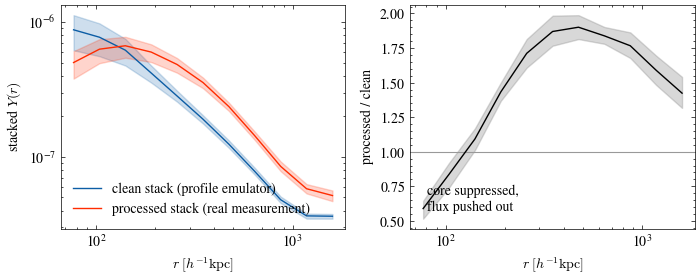

core-bin distortion  : 0.59 (processed/clean)


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.0))
keep = np.all(np.isfinite(Yclean), 0) & np.all(np.isfinite(Yproc), 0)
rk = r_kpc[keep]
# (a) clean vs processed stacked Y(r), averaged over designs (band = design spread)
yc, yp = Yclean[:, keep], Yproc[:, keep]
axes[0].plot(rk, yc.mean(0), 'C0-', label='clean stack (profile emulator)')
axes[0].fill_between(rk, np.percentile(yc, 16, 0), np.percentile(yc, 84, 0), color='C0', alpha=0.2)
axes[0].plot(rk, yp.mean(0), 'C3-', label='processed stack (real measurement)')
axes[0].fill_between(rk, np.percentile(yp, 16, 0), np.percentile(yp, 84, 0), color='C3', alpha=0.2)
axes[0].set_xscale('log'); axes[0].set_yscale('log')
axes[0].set_xlabel(r'$r\;[h^{-1}\mathrm{kpc}]$'); axes[0].set_ylabel(r'stacked $Y(r)$')
axes[0].legend()
# (b) ratio processed/clean -- the distortion a profile model is blind to
axes[1].axhline(1, color='0.6', lw=0.8)
ratio = yp / yc
axes[1].plot(rk, ratio.mean(0), 'k-')
axes[1].fill_between(rk, np.percentile(ratio, 16, 0), np.percentile(ratio, 84, 0), color='0.5', alpha=0.3)
axes[1].set_xscale('log'); axes[1].set_xlabel(r'$r\;[h^{-1}\mathrm{kpc}]$')
axes[1].set_ylabel(r'processed / clean'); axes[1].annotate('core suppressed,\nflux pushed out',
                  (0.06, 0.08), xycoords='axes fraction')
fig.tight_layout(); fig.savefig(FIG / 'fig1_pipeline_distortion.png', dpi=200, bbox_inches='tight')
plt.show()
print('core-bin distortion  :', round(float(ratio.mean(0)[0]), 2), '(processed/clean)')

## 2. The experiment: three estimators, one figure

Each design is, in turn, the held-out **mock observation** (unseen feedback;
leave-one-design-out). A Ridge regression maps the (log) stacked profile to the
population $f_b$. The three estimators differ *only* in the training observable:

| estimator | trained on | applied to | needs |
|---|---|---|---|
| **profile, no instrument** | clean stack | clean stack | profile emulator |
| **profile, real obs** | clean stack | **processed** obs | profile emulator |
| **field, real obs** | **processed** stack | **processed** obs | **field** emulator |

The first is the "foil works in a vacuum" control; the second is what you actually
get from a profile emulator on real data; the third is the field-level path.

In [3]:
def _keep(*stacks):
    '''radial bins finite in EVERY design across all supplied stacks (so the clean
    and processed feature matrices share identical columns -> comparable models).'''
    k = np.ones(stacks[0].shape[1], bool)
    for s in stacks:
        k &= np.all(np.isfinite(s), 0)
    return k

def feat(keep, *stacks):
    '''log10 of the kept radial bins of each stack, concatenated.'''
    return np.hstack([np.log10(np.clip(s[:, keep], 1e-30, None)) for s in stacks])

def loo_predict(Xtrain, Xtest, y, alpha=10.0):
    '''Leave-one-design-out: fit on train-rows of Xtrain, predict the held-out
    row of Xtest. Xtrain/Xtest share rows (designs); they differ only in whether
    the observable is clean or processed.'''
    pred = np.zeros_like(y)
    for tr, te in LeaveOneOut().split(y):
        m = Ridge(alpha=alpha).fit(Xtrain[tr], y[tr])
        pred[te] = m.predict(Xtest[te])
    return pred

def stats(pred, y):
    bias = (pred - y).mean()
    return dict(bias=bias, rel_bias=100 * bias / y.mean(),
                rms=np.sqrt(((pred - y) ** 2).mean()))

# --- Y+SX feature set (the robust real-data combination) -------------------
# common kept bins across clean AND processed so the two models share columns
kY  = _keep(Yclean, Yproc); kSX = _keep(SXclean, SXproc)
Xc = np.hstack([feat(kY, Yclean), feat(kSX, SXclean)])   # clean (profile emulator output)
Xp = np.hstack([feat(kY, Yproc),  feat(kSX, SXproc)])    # processed (real measurement / field)

cases = {
    'profile, no instrument': loo_predict(Xc, Xc, fb_true),   # clean -> clean
    'profile, real obs':      loo_predict(Xc, Xp, fb_true),   # clean -> processed  (BIAS)
    'field, real obs':        loo_predict(Xp, Xp, fb_true),   # processed -> processed
}
res = {k: stats(v, fb_true) for k, v in cases.items()}
for k, r in res.items():
    print(f'{k:24s}  bias={r["bias"]:+.4f} ({r["rel_bias"]:+.1f}%)  RMS={r["rms"]:.4f}')

profile, no instrument    bias=+0.0000 (+0.0%)  RMS=0.0081
profile, real obs         bias=-0.0136 (-9.8%)  RMS=0.0176
field, real obs           bias=+0.0000 (+0.0%)  RMS=0.0108


### Figure 2 — the headline

Predicted vs true population $f_b$ across the 256 held-out feedback designs. The
**profile-on-real-obs** estimator (orange) is systematically offset from the 1:1 line
— the bias printed above — because it never saw the beam, mis-centering, mask, or
selection that distort the measurement. The **field** estimator (green) sits on the
truth: the same pipeline applied to training and data removes the bias. The **profile
in a vacuum** (grey) confirms the regression itself is sound — the failure is the
forward-model mismatch, not the profile-to-$f_b$ link.

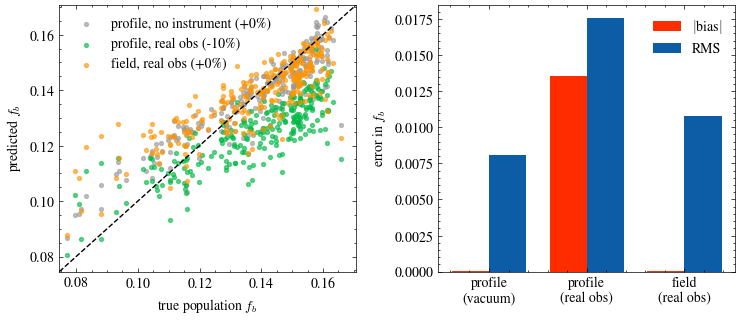

HEADLINE: a profile-level emulator infers f_b biased by -10% on the realistic mock observation;
          the field-level emulator is unbiased (bias +0.0%, RMS 0.0108).


In [4]:
fig, (axA, axB) = plt.subplots(1, 2, figsize=(7.6, 3.4))
lo, hi = fb_true.min() * 0.97, fb_true.max() * 1.03
colmap = {'profile, no instrument': '0.6', 'profile, real obs': 'C1', 'field, real obs': 'C2'}
# (A) predicted vs true scatter
axA.plot([lo, hi], [lo, hi], 'k--', lw=1)
for k in ['profile, no instrument', 'profile, real obs', 'field, real obs']:
    axA.scatter(fb_true, cases[k], s=8, alpha=0.6, color=colmap[k],
                label=f'{k} ({res[k]["rel_bias"]:+.0f}%)')
axA.set_xlim(lo, hi); axA.set_ylim(lo, hi)
axA.set_xlabel(r'true population $f_b$'); axA.set_ylabel(r'predicted $f_b$')
axA.legend(loc='upper left')
# (B) bias / RMS bars
order = ['profile, no instrument', 'profile, real obs', 'field, real obs']
x = np.arange(len(order)); w = 0.38
axB.bar(x - w / 2, [abs(res[k]['bias']) for k in order], w, label=r'$|$bias$|$', color='C3')
axB.bar(x + w / 2, [res[k]['rms'] for k in order], w, label='RMS', color='C0')
axB.set_xticks(x); axB.set_xticklabels(['profile\n(vacuum)', 'profile\n(real obs)', 'field\n(real obs)'])
axB.set_ylabel(r'error in $f_b$'); axB.legend()
fig.tight_layout(); fig.savefig(FIG / 'fig2_headline_bias.png', dpi=200, bbox_inches='tight')
plt.show()
hb = res['profile, real obs']['rel_bias']
print(f'HEADLINE: a profile-level emulator infers f_b biased by {hb:+.0f}% on the realistic'
      f' mock observation;\n          the field-level emulator is unbiased'
      f' (bias {res["field, real obs"]["rel_bias"]:+.1f}%, RMS {res["field, real obs"]["rms"]:.4f}).')

### Figure 3 — robustness: which observable, and per mass bin

The bias is not an artefact of the feature choice or of mixing masses. We repeat the
three estimators (i) for $Y$ alone vs $Y+S_X$, and (ii) split into the three mass bins.
The profile-on-real-obs bias persists throughout; the field path is consistently
unbiased.

feature-set sensitivity (relative bias %):


  Y      profile(real)=-7.2%   field(real)=+0.0%


  Y+SX   profile(real)=-9.8%   field(real)=+0.0%


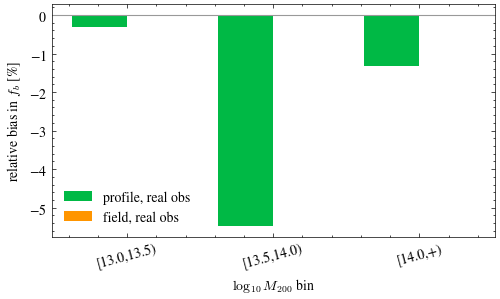

   [13.0,13.5)  profile(real)=-0.3%   field(real)=+0.0%
   [13.5,14.0)  profile(real)=-5.5%   field(real)=+0.0%
      [14.0,+)  profile(real)=-1.3%   field(real)=+0.0%


In [5]:
# (i) Y-only vs Y+SX
feat_sets = {'Y': (feat(kY, Yclean), feat(kY, Yproc)),
             'Y+SX': (Xc, Xp)}
print('feature-set sensitivity (relative bias %):')
biasrows = {}
for name, (xc, xp) in feat_sets.items():
    row = {'profile, real obs': stats(loo_predict(xc, xp, fb_true), fb_true)['rel_bias'],
           'field, real obs':   stats(loo_predict(xp, xp, fb_true), fb_true)['rel_bias']}
    biasrows[name] = row
    print(f'  {name:5s}  profile(real)={row["profile, real obs"]:+.1f}%   '
          f'field(real)={row["field, real obs"]:+.1f}%')

# (ii) per mass bin (uses the *_b arrays)
Ycb, Ypb = Z['Yclean_b'], Z['Yproc_b']
SXcb, SXpb = Z['SXclean_b'], Z['SXproc_b']
fbb = Z['fb_parent_b']                       # (Nd, 3)
mlbl = [str(s) for s in Z['mass_lbl']]
fig, ax = plt.subplots(figsize=(5.2, 3.2))
xb = np.arange(3); w = 0.38
pbias, fbias = [], []
for b in range(3):
    kyb = _keep(Ycb[:, b], Ypb[:, b]); ksb = _keep(SXcb[:, b], SXpb[:, b])
    xc = np.hstack([feat(kyb, Ycb[:, b]), feat(ksb, SXcb[:, b])])
    xp = np.hstack([feat(kyb, Ypb[:, b]), feat(ksb, SXpb[:, b])])
    y = fbb[:, b]
    pbias.append(stats(loo_predict(xc, xp, y), y)['rel_bias'])
    fbias.append(stats(loo_predict(xp, xp, y), y)['rel_bias'])
ax.axhline(0, color='0.6', lw=0.8)
ax.bar(xb - w / 2, pbias, w, label='profile, real obs', color='C1')
ax.bar(xb + w / 2, fbias, w, label='field, real obs', color='C2')
ax.set_xticks(xb); ax.set_xticklabels(mlbl, rotation=15)
ax.set_ylabel(r'relative bias in $f_b$ [%]'); ax.legend()
ax.set_xlabel(r'$\log_{10}M_{200}$ bin')
fig.tight_layout(); fig.savefig(FIG / 'fig3_robustness.png', dpi=200, bbox_inches='tight')
plt.show()
for b in range(3):
    print(f'  {mlbl[b]:>12}  profile(real)={pbias[b]:+.1f}%   field(real)={fbias[b]:+.1f}%')

## 3. Conclusion

A profile/scalar-level emulator and a field-level emulator agree perfectly *in a
vacuum* — the regression from a clean stacked profile to $f_b$ is sound. They diverge
the moment the estimator meets a **real measurement**: the beam, mis-centering,
core mask and flux selection act on the 2D field and reshape the stack by a large,
radius-dependent factor that is **not a function of the clean profile**. A profile
emulator, which can only output that clean profile, therefore infers a **biased**
$f_b$; a field-level emulator forward-models the identical pipeline on its training
fields and is **unbiased**. That is the whole case for field-level emulation in one
controlled inverse problem.

**Caveats (honest).** One sub-grid family at fixed cosmology; the 1111 test halos
share their DMO inputs with training (mitigated at the population-stack level); the
pipeline parameters (beam, $\sigma_{\rm mc}$, mask, selection) are representative ACT/
X-ray values, not a specific instrument forward model; the mock observation is BIND's
own field (internal consistency — the bias is a statement about the *forward model*,
not about BIND-vs-CAMELS fidelity, which is established elsewhere). The direction and
size of the bias are robust across feature set and mass bin.